### Download Data

In [ ]:
import requests
import zipfile
import os

url = "https://physionet.org/content/brugada-huca/get-zip/1.0.0/"
zip_path = "brugada-huca.zip"
extract_path = "brugada-huca"

# Download file
response = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(response.content)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Cek isi folder
os.listdir(extract_path)

In [25]:
import os
print(os.getcwd())

c:\Users\Ayuning Maretania Q\Documents\IDSC


               brugada
total              363
brugada_cases       69
normal_cases       287


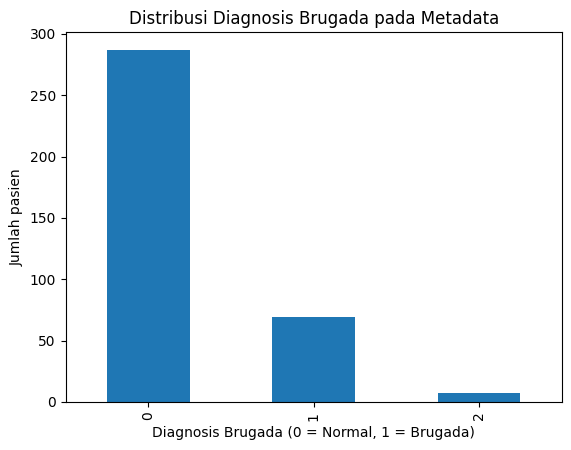

In [26]:
import pandas as pd

metadata_path = "C:/Users/Ayuning Maretania Q/Documents/IDSC/brugada-huca/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0/metadata.csv"

metadata = pd.read_csv(metadata_path)

metadata.head()

summary = metadata.agg(
    total=('brugada','count'),
    brugada_cases=('brugada', lambda x: (x==1).sum()),
    normal_cases=('brugada', lambda x: (x==0).sum())
)

print(summary)

### Distribusi Basal Pattern
metadata['basal_pattern'].value_counts()

### Distribusi Sudden Death
metadata['sudden_death'].value_counts()

import matplotlib.pyplot as plt

metadata['brugada'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Diagnosis Brugada (0 = Normal, 1 = Brugada)")
plt.ylabel("Jumlah pasien")
plt.title("Distribusi Diagnosis Brugada pada Metadata")

plt.show()


[251972, 265715, 267628, 286830]
[188981, 267630, 319150, 419960]


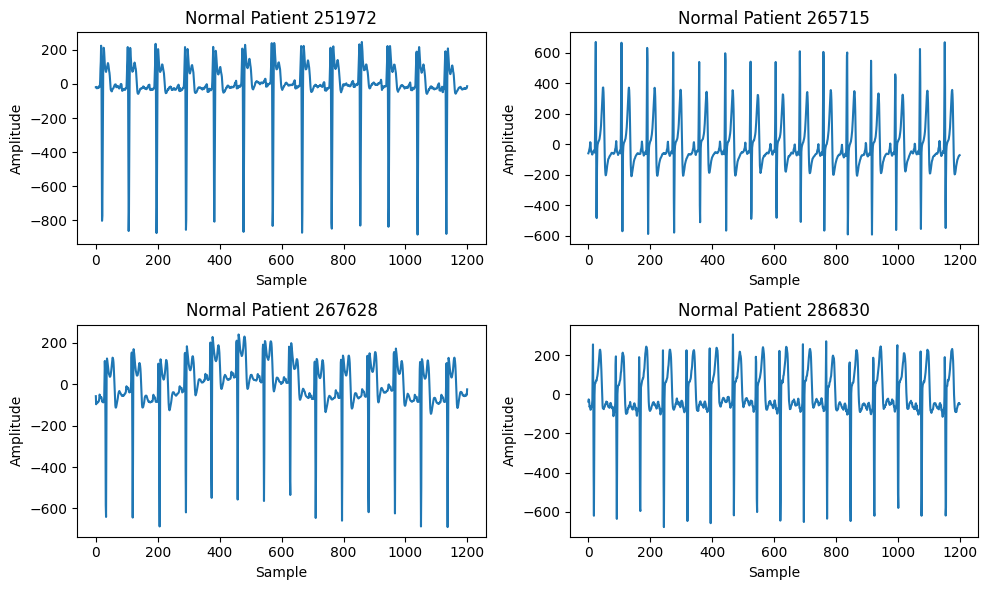

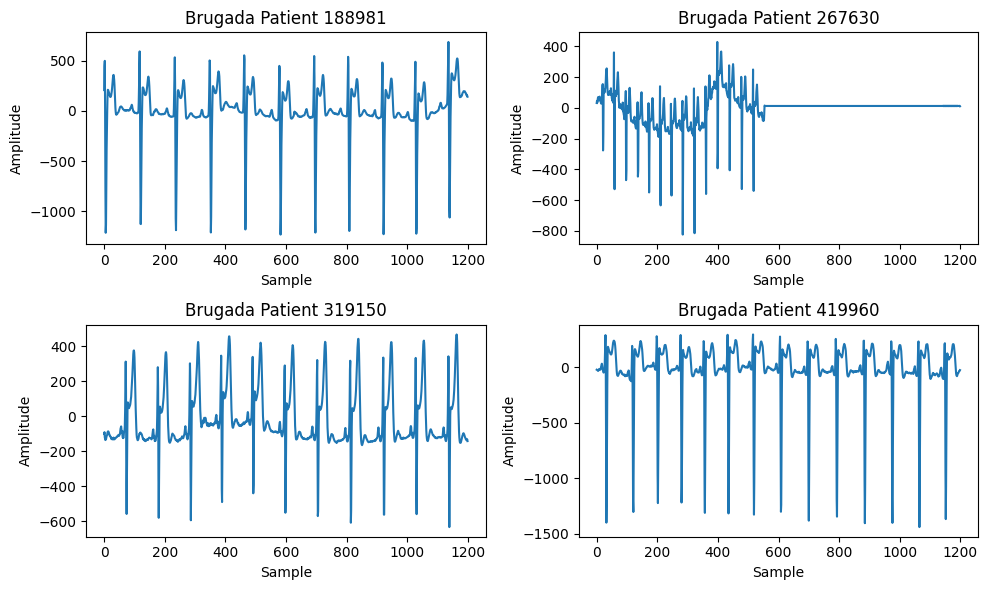

In [33]:
metadata.loc[metadata['brugada'] == 2, 'brugada'] = 1

metadata['brugada'].value_counts()

normal_ids = metadata[metadata['brugada']==0]['patient_id'].head(4).tolist()
brugada_ids = metadata[metadata['brugada']==1]['patient_id'].head(4).tolist()

print(normal_ids)
print(brugada_ids)

import numpy as np


### Membaca FIle ECG
def read_ecg(patient_id, folder="C:/Users/Ayuning Maretania Q/Documents/IDSC/brugada-huca/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0/files/"):
    
    path = f"{folder}{patient_id}/{patient_id}.dat"
    
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    
    ecg = np.fromfile(path, dtype=np.int16, count=1200*12)
    
    ecg_matrix = ecg.reshape(-1,12)
    
    leads = ["I","II","III","aVR","aVL","aVF",
             "V1","V2","V3","V4","V5","V6"]
    
    return pd.DataFrame(ecg_matrix, columns=leads)

ecg_normal_list = [read_ecg(pid) for pid in normal_ids]
ecg_brugada_list = [read_ecg(pid) for pid in brugada_ids]
ecg_all_list = [read_ecg(pid) for pid in metadata["patient_id"].values]

### Plot ECG Pasien Normal
fig, axes = plt.subplots(2,2, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):
    ax.plot(ecg_normal_list[i]["V2"])
    ax.set_title(f"Normal Patient {normal_ids[i]}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Plot ECG PAsien Brugada
fig, axes = plt.subplots(2,2, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):
    ax.plot(ecg_brugada_list[i]["V2"])
    ax.set_title(f"Brugada Patient {brugada_ids[i]}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


In [62]:
import wfdb
import numpy as np

def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    ecg = record.p_signal   # (time, 12 leads)
    fs = record.fs
    return ecg, fs

def get_single_lead(ecg, lead_name="II", lead_names=None):
    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    
    idx = lead_names.index(lead_name)
    return ecg[:, idx]

import neurokit2 as nk

def get_rpeaks(signal, fs):
    clean = nk.ecg_clean(signal, sampling_rate=fs)
    signals, info = nk.ecg_peaks(clean, sampling_rate=fs)
    return info["ECG_R_Peaks"]

import numpy as np

def extract_ecg_features(signal, fs):
    
    rpeaks = get_rpeaks(signal, fs)
        
    # ===== RR INTERVAL =====
    rr = np.diff(rpeaks) / fs if len(rpeaks) > 1 else [0]
    
    # ===== HEART RATE =====
    hr = 60 / np.mean(rr) if len(rr) > 0 else 0
    
    # ===== QRS DURATION (approx) =====
    qrs = np.mean(np.diff(rpeaks)) / fs if len(rpeaks) > 1 else 0
    
    # ===== ST SEGMENT (simple approx) =====
    st_points = []
    for r in rpeaks:
        st_idx = r + int(0.06 * fs)
        if st_idx < len(signal):
            window = signal[max(0, st_idx-3):min(len(signal), st_idx+3)]
            st_points.append(np.mean(window))
    
    st = np.percentile(st_points, 75) - np.percentile(st_points, 25) if len(st_points) > 0 else 0
    # ===== R-PEAK AMPLITUDE =====
    r_amp = np.mean([signal[r] for r in rpeaks]) if len(rpeaks) > 0 else 0

    # ===== SIGNAL ENERGY =====
    energy = np.mean(signal**2)

    # ===== SKEWNESS (morphology) =====
    skew = np.mean((signal - np.mean(signal))**3)
    
    #  RR SECOND-ORDER VARIABILITY
    if len(rpeaks) > 2:
        rr_diff = np.diff(np.diff(rpeaks)) / fs
        rr_var2 = np.std(rr_diff)
    else:
        rr_var2 = 0
        
    return np.array([
    hr, np.mean(rr), np.std(rr),
    qrs, st,
    r_amp, energy, skew
])

def build_features(record_list, folder):
    
    X = []
    
    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    selected_leads = ["V1", "V2", "V3"]
    
    for record_id in record_list:
        
        path = f"{folder}/{record_id}/{record_id}"
        ecg, fs = load_ecg(path)
        
        features = []
        
        for lead in selected_leads:
            idx = lead_names.index(lead)
            signal = ecg[:, idx]
            signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
            
            feat = extract_ecg_features(signal, fs)
            
            # safety biar gak error
            feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
            
            features.append(feat)
        
        # gabung V1-V3
        features = np.concatenate(features)
        
        X.append(features)
    
    return np.array(X, dtype=np.float32)

X = build_features(train_ids, data_folder)

import numpy as np

X = np.array(X)
y = np.array(y_train).astype(int).ravel()

from sklearn.model_selection import train_test_split

X_train = build_features(train_ids, data_folder)
X_test  = build_features(test_ids, data_folder)

y_train = np.array([labels_dict[pid] for pid in train_ids])
y_test  = np.array([labels_dict[pid] for pid in test_ids])


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = X_train_scaled, y_train


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric="auc",
    random_state=42
    )

}


from sklearn.metrics import f1_score, recall_score, roc_auc_score, classification_report

results = {}

for name, model in models.items():
    print(f"\n=== {name} ===")

    # TRAIN
    model.fit(X_resampled, y_resampled)

    # PREDICT
    y_pred = model.predict(X_test_scaled)

    # PROBABILITY
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    # ===== METRICS =====
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"F1-score    : {f1:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"ROC-AUC     : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results[name] = {
        "model": model,
        "f1": f1,
        "recall": recall,
        "auc": auc
    }


sorted_results = sorted(results.items(), key=lambda x: x[1]["auc"], reverse=True)

print("\n=== FINAL RANKING ===")

for name, res in sorted_results:
    print(name)
    print(f"  F1     : {res['f1']:.4f}")
    print(f"  Recall : {res['recall']:.4f}")
    print(f"  AUC    : {res['auc']:.4f}\n")

print("LEADS: V1-V3")
print("X shape:", X.shape)
print("Train/Test:", len(train_ids), len(test_ids))
print("Leak check:", len(set(train_ids)&set(test_ids)))

C:\Users\Ayuning Maretania Q\AppData\Local\Temp\ipykernel_16924\4222529211.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  hr = 60 / np.mean(rr) if len(rr) > 0 else 0
C:\Users\Ayuning Maretania Q\AppData\Local\Temp\ipykernel_16924\4222529211.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  hr = 60 / np.mean(rr) if len(rr) > 0 else 0



=== Logistic Regression ===
F1-score    : 0.5106
Recall      : 0.8000
ROC-AUC     : 0.8046

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77        58
           1       0.38      0.80      0.51        15

    accuracy                           0.68        73
   macro avg       0.65      0.73      0.64        73
weighted avg       0.81      0.68      0.71        73


=== Random Forest ===
F1-score    : 0.2353
Recall      : 0.1333
ROC-AUC     : 0.8034

Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        58
           1       1.00      0.13      0.24        15

    accuracy                           0.82        73
   macro avg       0.91      0.57      0.57        73
weighted avg       0.85      0.82      0.76        73


=== XGBoost ===
F1-score    : 0.5806
Recall      : 0.6000
ROC-AUC     : 0.8011

Classification Report:
              pr

### full deep learning ECG model

In [42]:
import numpy as np

def extract_windows(signal, rpeaks, fs, pre=0.25, post=0.45):
    windows = []
    for r in rpeaks:
        start = int(r - pre * fs)
        end = int(r + post * fs)

        if start >= 0 and end < len(signal):
            windows.append(signal[start:end])

    return np.array(windows)
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(ch)
        self.conv2 = nn.Conv1d(ch, ch, 7, padding=3)
        self.bn2 = nn.BatchNorm1d(ch)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)
class ECGEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.resblocks = nn.Sequential(
            ResBlock(64),
            ResBlock(64),
            ResBlock(64)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.resblocks(x)
        return x
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        # x: (batch, time, dim)
        weights = self.attn(x)
        weights = torch.softmax(weights, dim=1)

        out = torch.sum(weights * x, dim=1)
        return out
class ECGModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = ECGEncoder()
        self.pool = AttentionPool(64)

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, 1, time)
        feat = self.encoder(x)          # (B, C, T)
        feat = feat.permute(0, 2, 1)    # (B, T, C)

        pooled = self.pool(feat)        # (B, C)

        out = self.classifier(pooled)
        return torch.sigmoid(out)

import torch
import torch.nn as nn

import numpy as np
import torch

num_pos = np.sum(y_train == 1)
num_neg = np.sum(y_train == 0)

pos_weight = num_neg / num_pos
pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


def augment(x):
    if np.random.rand() < 0.5:
        x = x + np.random.normal(0, 0.01, x.shape)

    if np.random.rand() < 0.5:
        x = np.roll(x, np.random.randint(-20, 20))

    if np.random.rand() < 0.5:
        x = x * np.random.uniform(0.9, 1.1)

    return x

def augment_signal(x):
    if np.random.rand() < 0.5:
        x = x + np.random.normal(0, 0.01, x.shape)

    if np.random.rand() < 0.5:
        x = np.roll(x, np.random.randint(-10, 10), axis=-1)

    if np.random.rand() < 0.5:
        x = x * np.random.uniform(0.9, 1.1)

    return x

def build_mil_dataset(record_ids, data_folder, metadata):

    X_dict = {}
    y_dict = {}

    for pid in record_ids:

        path = f"{data_folder}/{pid}/{pid}"

        ecg, fs = load_ecg(path)
        signal = get_single_lead(ecg)
        rpeaks = get_rpeaks(signal, fs)

        beats = extract_windows(signal, rpeaks, fs)

        if len(beats) < 5:
            continue

        beats = (beats - beats.mean(axis=1, keepdims=True)) / (beats.std(axis=1, keepdims=True) + 1e-6)

        X_dict[pid] = beats

        label = metadata.set_index("patient_id").loc[pid, "brugada"]
        y_dict[pid] = int(label)

    return X_dict, y_dict

X_dict, y_dict = build_mil_dataset(train_ids, data_folder, metadata)

print("Total patients:", len(X_dict))

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch

train_ids, val_ids = train_test_split(
    list(X_dict.keys()),
    test_size=0.2,
    random_state=42,
    stratify=[y_dict[k] for k in X_dict.keys()]
)
from torch.utils.data import Dataset
import torch

class ECG_MIL_Dataset(Dataset):
    def __init__(self, X_dict, y_dict):
        self.ids = list(X_dict.keys())
        self.X = X_dict
        self.y = y_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]

        beats = torch.tensor(self.X[pid], dtype=torch.float32)
        beats = beats.unsqueeze(1)

        label = torch.tensor(self.y[pid], dtype=torch.float32)

        return beats, label
    
def collate_fn(batch):
    beats, labels = zip(*batch)
    return list(beats), torch.stack(labels)

train_dataset = ECG_MIL_Dataset(
    {k: X_dict[k] for k in train_ids},
    {k: y_dict[k] for k in train_ids}
)

val_dataset = ECG_MIL_Dataset(
    {k: X_dict[k] for k in val_ids},
    {k: y_dict[k] for k in val_ids}
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

import torch.nn as nn
import torch.nn.functional as F

class ECGModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 64, 7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU()
            )

        self.attn = nn.Linear(64, 1)

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, beats_list):

        outputs = []

        for beats in beats_list:
            feats = self.encoder(beats)
            feats = feats.mean(dim=-1)

            attn = torch.softmax(self.attn(feats), dim=0)
            pooled = torch.sum(attn * feats, dim=0)

            out = self.classifier(pooled)
            outputs.append(out)

        return torch.stack(outputs).squeeze()
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGModel().to(device)

num_pos = sum(y_dict[k] for k in train_ids)
num_neg = len(train_ids) - num_pos

pos_weight = torch.tensor([num_neg / num_pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train(model, train_loader, val_loader, optimizer, criterion, device)
print("Sample preds:", y_pred[:10])
print("Sample labels:", y_true[:10])

val_auc, y_true, y_pred = evaluate(model, val_loader, device)

best_t, best_f1 = find_best_threshold(y_true, y_pred)

print("Val AUC:", val_auc)
print("Best threshold:", best_t)
print("Best F1:", best_f1)





Total patients: 173
Epoch 0 | Loss 20.1105 | Val AUC 0.3469
Epoch 1 | Loss 20.0243 | Val AUC 0.3367
Epoch 2 | Loss 19.2943 | Val AUC 0.3265
Epoch 3 | Loss 19.9280 | Val AUC 0.3163
Epoch 4 | Loss 20.5802 | Val AUC 0.3316
Epoch 5 | Loss 19.8331 | Val AUC 0.3214
Epoch 6 | Loss 20.4957 | Val AUC 0.3112
Epoch 7 | Loss 20.4221 | Val AUC 0.3010
Early stopping triggered
Sample preds: [0 0 0 0 1 0 0 1 1 1]
Sample labels: [0. 0. 0. 0. 0. 1. 1. 0. 0. 0.]
Val AUC: 0.30102040816326525
Best threshold: 0.1
Best F1: 0.3333333333333333
